# Attention-Augmented CNN for CIFAR-10: Experiments

This notebook runs training experiments, compares baseline vs. attention-augmented CNNs, and visualizes results including training curves, ablation studies, and attention maps.

In [1]:
import sys
import os
import json
from pathlib import Path

# Add project root to path so we can import src
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["figure.dpi"] = 100

from src import BaselineCNN, AttentionCNN, get_model, count_parameters
from src.train import train, get_dataloaders, evaluate, get_device, set_seed

RESULTS_DIR = Path("../results")
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

device = get_device()
print(f"Using device: {device}")

Using device: mps


## 1. Model Overview & Parameter Counts

Verify architectures and compare parameter counts across configurations.

In [2]:
# Define all experiment configurations for ablation study
CONFIGS = {
    "baseline": {
        "model_type": "baseline",
        "run_name": "baseline",
    },
    "spatial_attn_pos12": {
        "model_type": "attention",
        "attention_type": "spatial",
        "attention_positions": [1, 2],
        "run_name": "spatial_attn_pos12",
    },
    "spatial_attn_pos1": {
        "model_type": "attention",
        "attention_type": "spatial",
        "attention_positions": [1],
        "run_name": "spatial_attn_pos1",
    },
    "spatial_attn_pos2": {
        "model_type": "attention",
        "attention_type": "spatial",
        "attention_positions": [2],
        "run_name": "spatial_attn_pos2",
    },
    "spatial_attn_pos012": {
        "model_type": "attention",
        "attention_type": "spatial",
        "attention_positions": [0, 1, 2],
        "run_name": "spatial_attn_pos012",
    },
    "channel_attn_pos12": {
        "model_type": "attention",
        "attention_type": "channel",
        "attention_positions": [1, 2],
        "run_name": "channel_attn_pos12",
    },
}

# Shared training hyperparameters
SHARED = {
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.5,
    "num_workers": 2,
    "data_dir": "../data",
    "save_dir": "../results",
    "seed": 42,
}

# Show parameter counts
print(f"{'Config':<25} {'Params':>10}")
print("-" * 37)
for name, cfg in CONFIGS.items():
    model = get_model(cfg)
    print(f"{name:<25} {count_parameters(model):>10,}")

Config                        Params
-------------------------------------
baseline                   2,361,162
spatial_attn_pos12         2,411,082
spatial_attn_pos1          2,377,802
spatial_attn_pos2          2,394,442
spatial_attn_pos012        2,419,402
channel_attn_pos12         2,371,402


## 2. Training

Train all configurations. Each run saves a `_results.json` file and a `_best.pt` checkpoint. If results already exist for a config, that run is skipped.

In [3]:
all_results = {}

for name, cfg in CONFIGS.items():
    results_path = RESULTS_DIR / f"{name}_results.json"

    # Skip if already trained
    if results_path.exists():
        print(f"[{name}] Loading existing results from {results_path}")
        with open(results_path) as f:
            all_results[name] = json.load(f)
        continue

    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    full_config = {**SHARED, **cfg}
    all_results[name] = train(full_config)

print("\nAll runs complete.")

[baseline] Loading existing results from ../results/baseline_results.json
[spatial_attn_pos12] Loading existing results from ../results/spatial_attn_pos12_results.json
[spatial_attn_pos1] Loading existing results from ../results/spatial_attn_pos1_results.json
[spatial_attn_pos2] Loading existing results from ../results/spatial_attn_pos2_results.json
[spatial_attn_pos012] Loading existing results from ../results/spatial_attn_pos012_results.json
[channel_attn_pos12] Loading existing results from ../results/channel_attn_pos12_results.json

All runs complete.


## 3. Training Curves

Plot training/test loss and accuracy over epochs for all configurations.

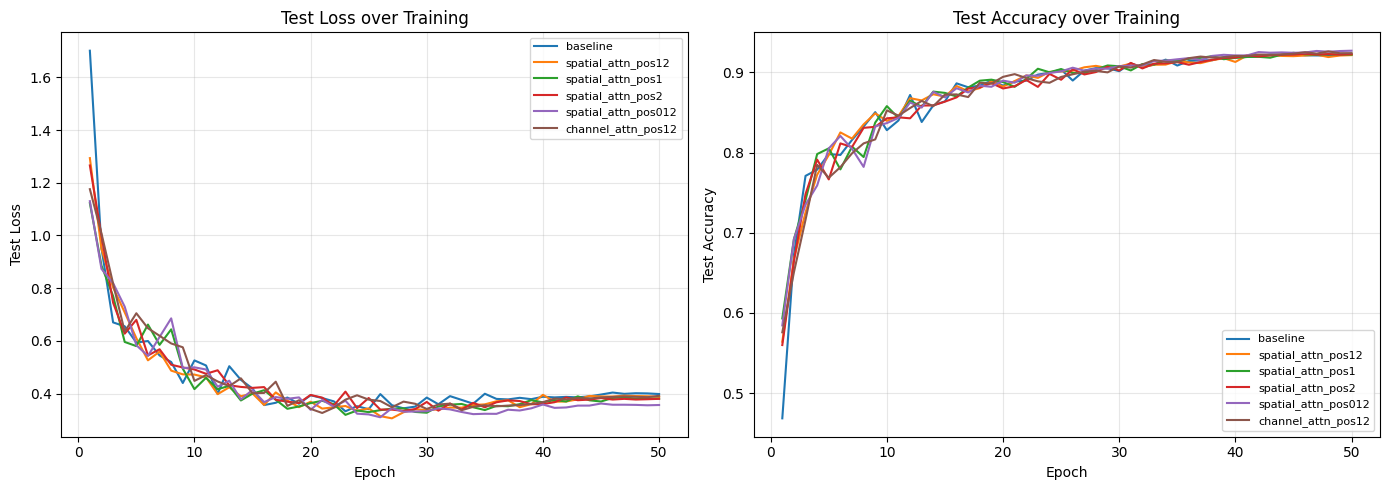

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in all_results.items():
    epochs = range(1, len(res["history"]["train_loss"]) + 1)
    axes[0].plot(epochs, res["history"]["test_loss"], label=name)
    axes[1].plot(epochs, res["history"]["test_acc"], label=name)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test Loss")
axes[0].set_title("Test Loss over Training")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Test Accuracy over Training")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_curves.png", bbox_inches="tight")
plt.show()

## 4. Ablation Results Table

Summary table comparing all configurations: parameter count, best test accuracy.

Config                        Params  Best Test Acc
---------------------------------------------------
spatial_attn_pos012        2,419,402        0.9270
channel_attn_pos12         2,371,402        0.9262
spatial_attn_pos1          2,377,802        0.9244
spatial_attn_pos2          2,394,442        0.9232
baseline                   2,361,162        0.9229
spatial_attn_pos12         2,411,082        0.9221


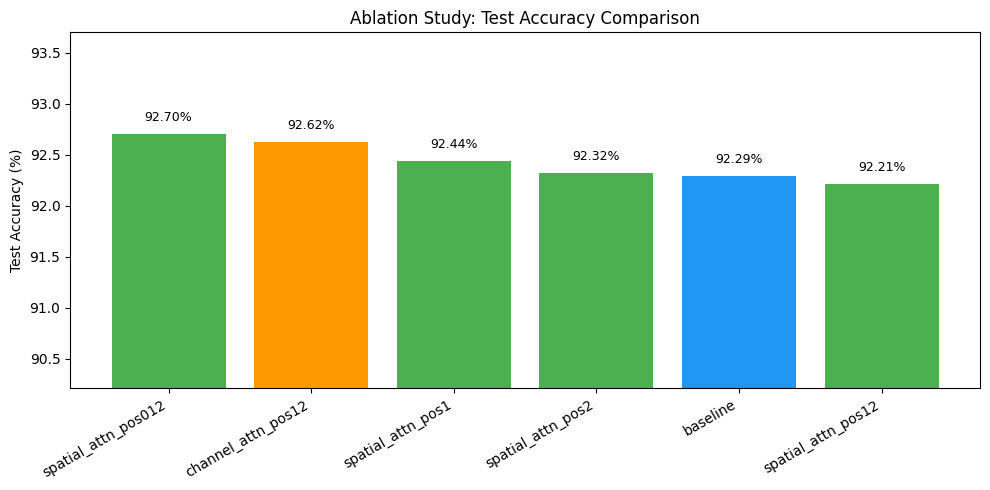

In [5]:
# Build summary table
print(f"{'Config':<25} {'Params':>10} {'Best Test Acc':>14}")
print("-" * 51)

# Sort by accuracy descending
sorted_results = sorted(all_results.items(), key=lambda x: x[1]["best_test_accuracy"], reverse=True)
for name, res in sorted_results:
    params = res["num_params"]
    acc = res["best_test_accuracy"]
    print(f"{name:<25} {params:>10,} {acc:>13.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = [r[0] for r in sorted_results]
accs = [r[1]["best_test_accuracy"] * 100 for r in sorted_results]
colors = ["#2196F3" if "baseline" in n else "#4CAF50" if "spatial" in n else "#FF9800" for n in names]
bars = ax.bar(names, accs, color=colors)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Ablation Study: Test Accuracy Comparison")
ax.set_ylim(min(accs) - 2, max(accs) + 1)
plt.xticks(rotation=30, ha="right")

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{acc:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "ablation_comparison.png", bbox_inches="tight")
plt.show()

## 5. Per-Class Accuracy Comparison

Compare per-class accuracy between baseline and the best attention model.

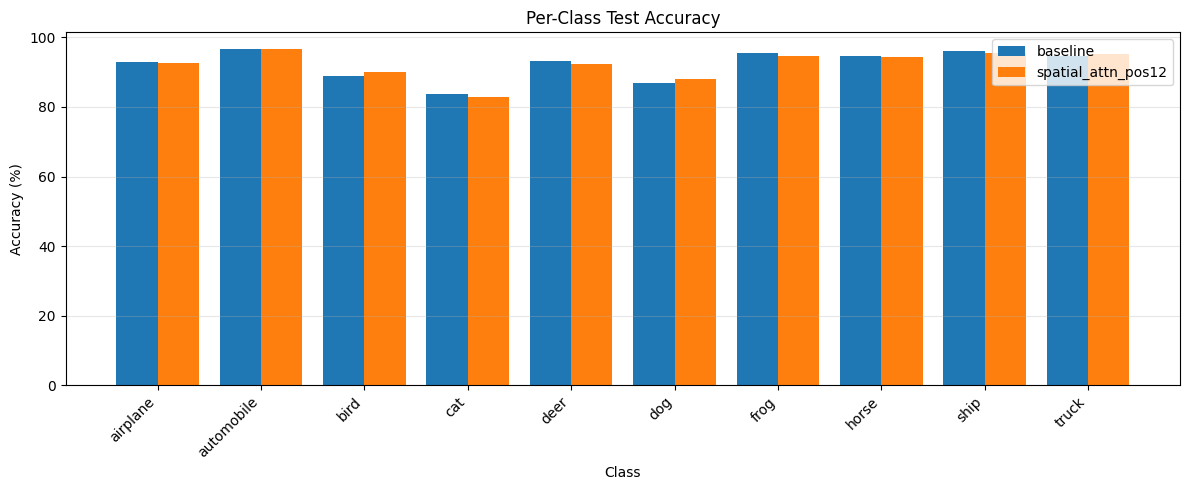

In [6]:
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# Compare baseline vs best attention model
configs_to_compare = ["baseline", "spatial_attn_pos12"]
existing = [c for c in configs_to_compare if c in all_results]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(CIFAR10_CLASSES))
width = 0.8 / len(existing)

for i, name in enumerate(existing):
    per_class = all_results[name]["per_class_accuracy"]
    # Handle both int keys (from train()) and string keys (from JSON)
    accs = [per_class.get(str(j), per_class.get(j, 0)) * 100 for j in range(10)]
    offset = (i - len(existing) / 2 + 0.5) * width
    ax.bar(x + offset, accs, width, label=name)

ax.set_xlabel("Class")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Test Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "per_class_accuracy.png", bbox_inches="tight")
plt.show()

## 6. Attention Map Visualization

Visualize spatial self-attention maps overlaid on input images. The attention maps show which spatial positions the model attends to for a given query position.

Loaded checkpoint.


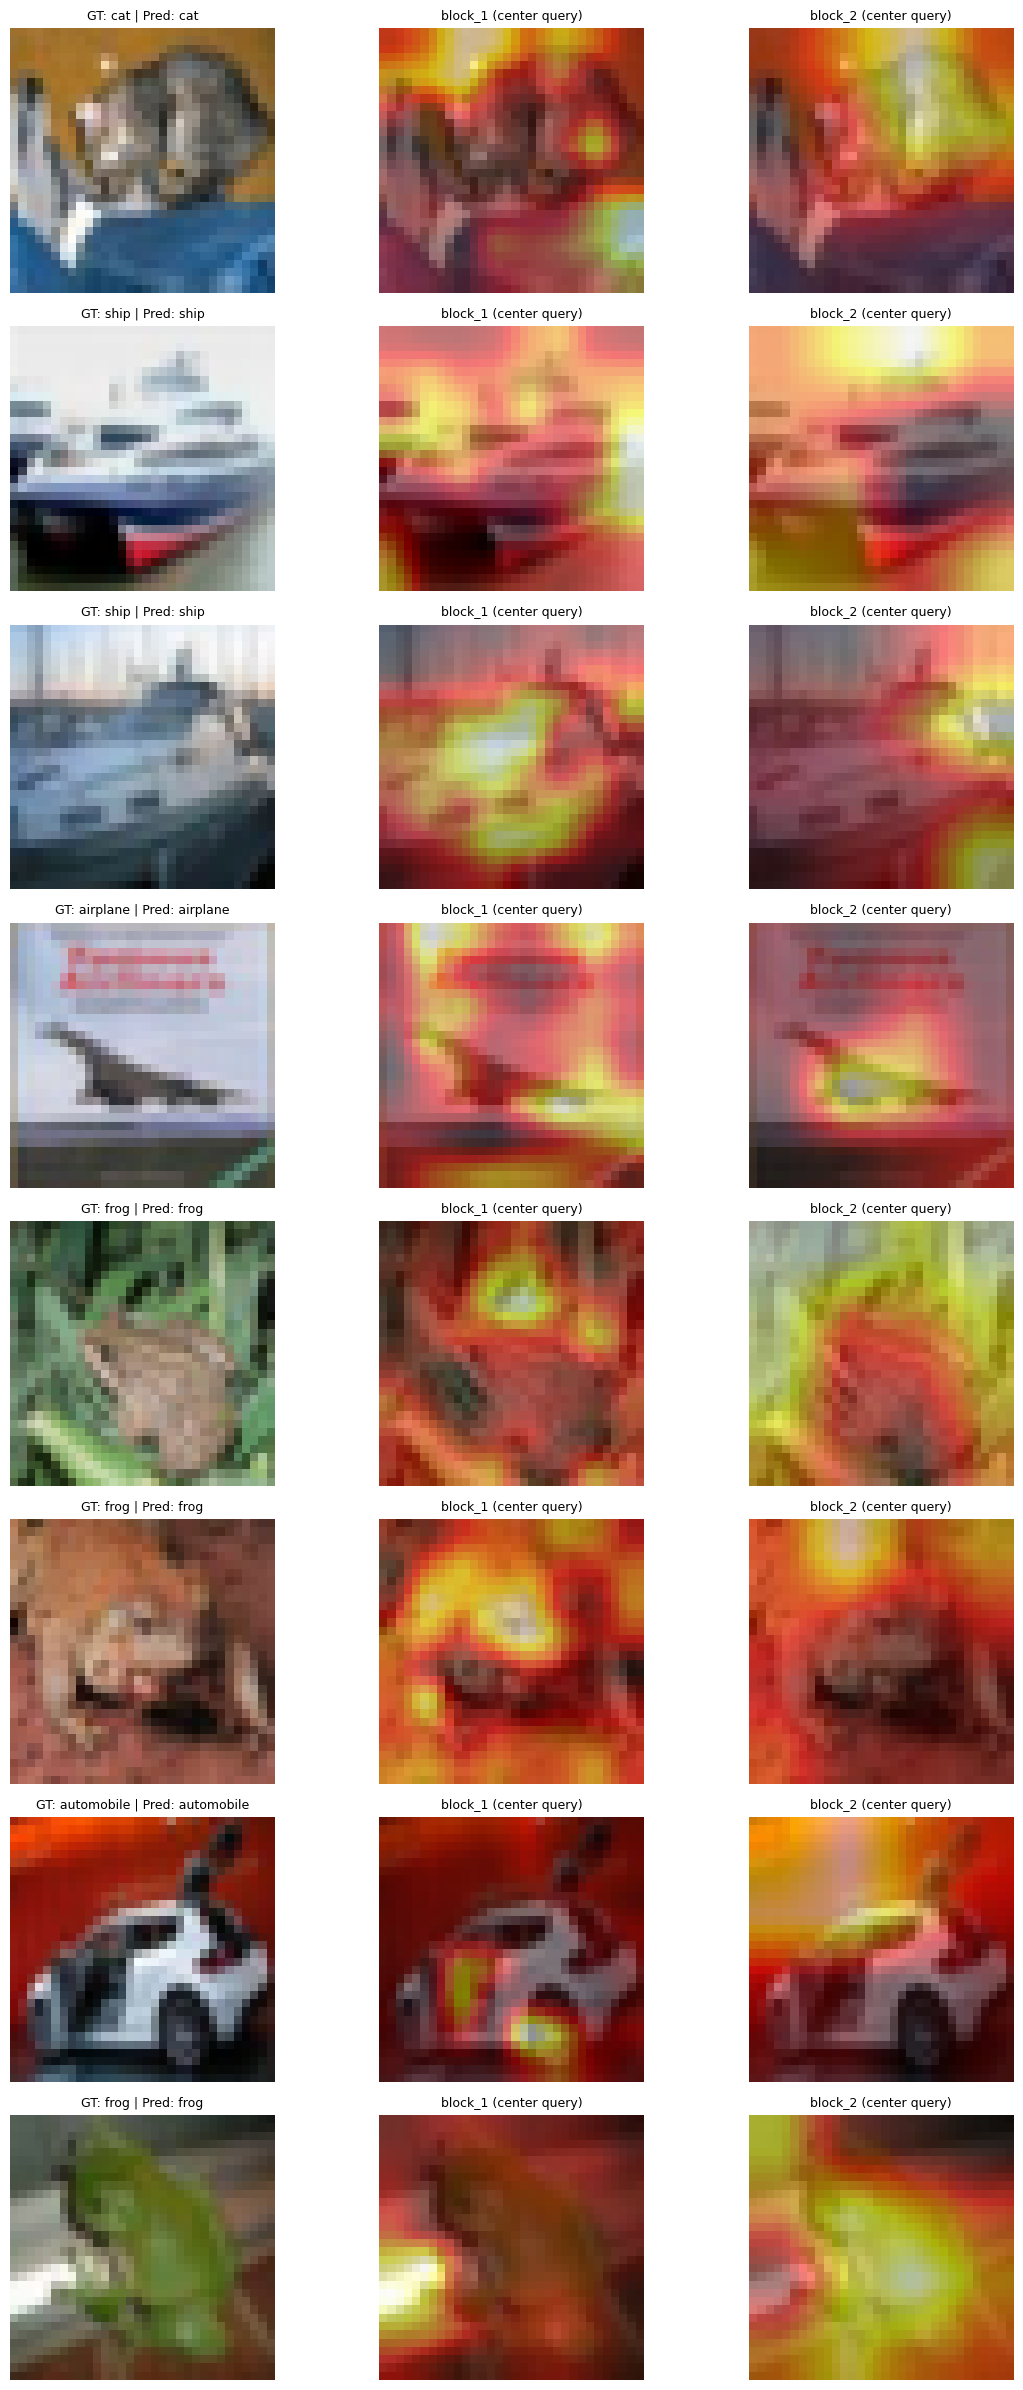

In [7]:
from torchvision.transforms import functional as TF, InterpolationMode
from src.train import CIFAR10_MEAN, CIFAR10_STD

# Free MPS memory from previous cells before running visualization
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

def denormalize(img_tensor):
    """Convert normalized tensor back to displayable [0,1] image."""
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1)

# Load the best attention model — use CPU to avoid MPS OOM crash
vis_device = torch.device("cpu")

attn_config = {**CONFIGS["spatial_attn_pos12"]}
model = get_model(attn_config)
ckpt_path = RESULTS_DIR / "spatial_attn_pos12_best.pt"
if ckpt_path.exists():
    model.load_state_dict(torch.load(ckpt_path, map_location="cpu", weights_only=True))
    print("Loaded checkpoint.")
else:
    print("No checkpoint found — run training first.")
model.eval()
model = model.to(vis_device)

# Get test images (small batch, no GPU needed)
_, test_loader = get_dataloaders(batch_size=8, num_workers=0, data_dir="../data")
images, labels = next(iter(test_loader))

with torch.no_grad():
    logits, attn_maps = model(images.to(vis_device))
    preds = logits.argmax(dim=1).cpu()

# Visualize attention maps for each image
n_images = min(8, len(images))
attn_keys = sorted(attn_maps.keys())

if attn_keys:
    fig, axes = plt.subplots(n_images, len(attn_keys) + 1, figsize=(4 * (len(attn_keys) + 1), 3 * n_images))
    if n_images == 1:
        axes = axes[np.newaxis, :]

    for i in range(n_images):
        # Original image
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"GT: {CIFAR10_CLASSES[labels[i]]} | Pred: {CIFAR10_CLASSES[preds[i]]}", fontsize=9)
        axes[i, 0].axis("off")

        # Attention maps — average over heads, pick center query position
        for j, key in enumerate(attn_keys):
            attn = attn_maps[key][i].cpu()  # (heads, N, N)
            attn_avg = attn.mean(dim=0)     # (N, N) — average over heads
            H = W = int(attn_avg.shape[0] ** 0.5)
            center = H * (H // 2) + W // 2  # center query position
            attn_map = attn_avg[center].reshape(H, W).numpy()

            # Upsample attention map to image size for overlay
            attn_resized = TF.resize(
                torch.tensor(attn_map).unsqueeze(0),
                [32, 32],
                interpolation=InterpolationMode.BILINEAR,
            ).squeeze().numpy()

            axes[i, j + 1].imshow(img)
            axes[i, j + 1].imshow(attn_resized, cmap="hot", alpha=0.5)
            axes[i, j + 1].set_title(f"{key} (center query)", fontsize=9)
            axes[i, j + 1].axis("off")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "attention_maps.png", bbox_inches="tight")
    plt.show()
else:
    print("No attention maps available.")